# Customer Churn Prediction using Machine Learning

### Predicting Customer Churn with Python and Scikit-learn

**Author:** Nitheeshwaran V

**Project Type:** Data Analytics & Machine Learning

**Tools & Technologies:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Jupyter Notebook

**Dataset:** IBM Telco Customer Churn Dataset

**Objective:**
Develop a machine learning model to predict whether a customer is likely to leave a company based on demographic, account, and service usage data. The project includes data cleaning, exploratory data analysis (EDA), feature engineering, model building, evaluation, and business insights.

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully!")

Libraries imported successfully!


In [1]:
# Load the Dataset

import pandas as pd
df = pd.read_excel("Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


# Data Understanding

This section explores the dataset to understand its structure, identify the target variable, examine feature types, and gain insights before data cleaning and modeling.

In [2]:
# Dataset Overview

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df.shape

(7043, 33)

In [4]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [7]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# Unique Values Analysis
df.nunique()

CustomerID           7043
Count                   1
Country                 1
State                   1
City                 1129
Zip Code             1652
Lat Long             1652
Latitude             1652
Longitude            1651
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          73
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6531
Churn Label             2
Churn Value             2
Churn Score            85
CLTV                 3438
Churn Reason           20
dtype: int64

In [10]:
# Sample Data
df.sample(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2074,4716-HHKQH,1,United States,California,Pomona,91767,"34.083086, -117.737997",34.083086,-117.737997,Male,...,Month-to-month,No,Electronic check,107.05,2172.05,No,0,65,5328,NaN
258,9524-EGPJC,1,United States,California,Walnut Creek,94595,"37.862128, -122.075197",37.862128,-122.075197,Female,...,Month-to-month,Yes,Electronic check,90.10,1612.75,Yes,1,80,4260,Competitor offered higher download speeds
4584,2364-UFROM,1,United States,California,San Diego,92123,"32.808814, -117.134694",32.808814,-117.134694,Male,...,One year,No,Electronic check,70.40,2044.75,No,0,68,3380,NaN
6688,8709-KRDVL,1,United States,California,Scott Bar,96085,"41.737962, -123.07557",41.737962,-123.075570,Female,...,Month-to-month,Yes,Electronic check,100.00,3320.6,No,0,76,4643,NaN
462,7198-GLXTC,1,United States,California,La Palma,90623,"33.850504, -118.039892",33.850504,-118.039892,Male,...,Month-to-month,No,Electronic check,79.00,143.65,Yes,1,92,5239,Attitude of support person


In [20]:
# Target Variable
df.columns = df.columns.str.strip()
print(df.columns.tolist())


['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


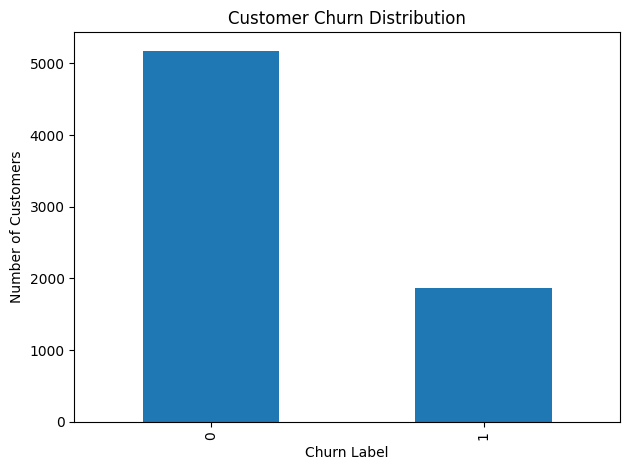

In [125]:
# Customer Churn Distribution
import matplotlib.pyplot as plt

df["Churn Label"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Label")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("images/churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
#  Numerical Features
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_columns)

Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
       'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV'],
      dtype='object')


In [24]:
# Categorical Features
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender',
       'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges', 'Churn Label', 'Churn Reason'],
      dtype='object')


| Feature | Description |
|----------|-------------|
| CustomerID | Unique customer identifier |
| Gender | Customer gender |
| Age | Customer age |
| Contract | Contract type |
| Monthly Charges | Monthly subscription fee |
| Total Charges | Total amount paid |
| Churn Label | Target variable |


In [31]:
# Class Distribution
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [32]:
# Check missing values in each column
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [33]:
# Count duplicate rows
df.duplicated().sum()

np.int64(0)

In [34]:
# Remove duplicate rows
df = df.drop_duplicates()

# Verify duplicates are removed
df.duplicated().sum()

np.int64(0)

In [35]:
# Display data types
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [80]:
# Check data type
print(df["Total Charges"].dtype)

float64


In [38]:
# Convert Total Charges to numeric
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [39]:
df["Total Charges"].dtype

dtype('float64')

In [42]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [43]:
# Display first five rows
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [44]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

# 8. Exploratory Data Analysis (EDA)

## 8.1 Churn Distribution

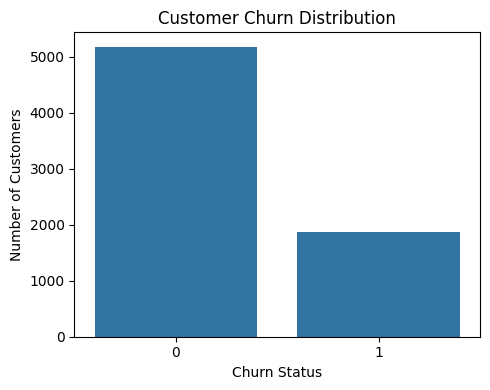

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(5,4))
sns.countplot(x="Churn Label", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("images/Customer_churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

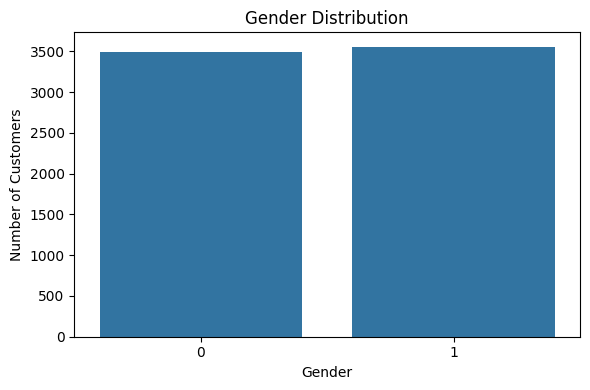

In [156]:
# Gender Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("images/Gender_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

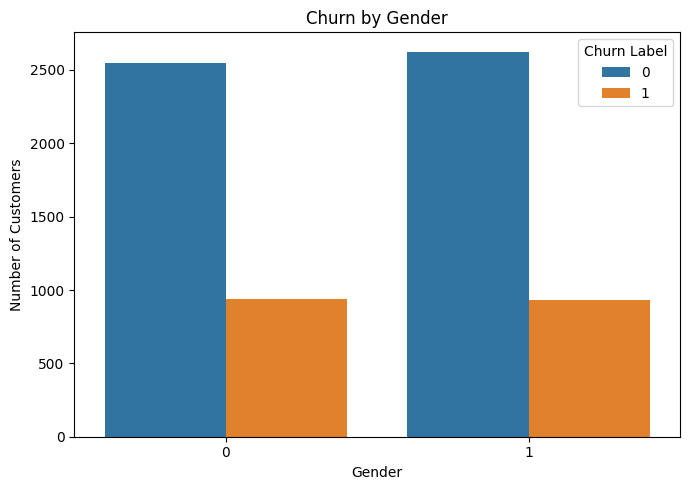

In [158]:
# Churn by Gender
plt.figure(figsize=(7,5))
sns.countplot(x="Gender", hue="Churn Label", data=df)
plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("images/Gender_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

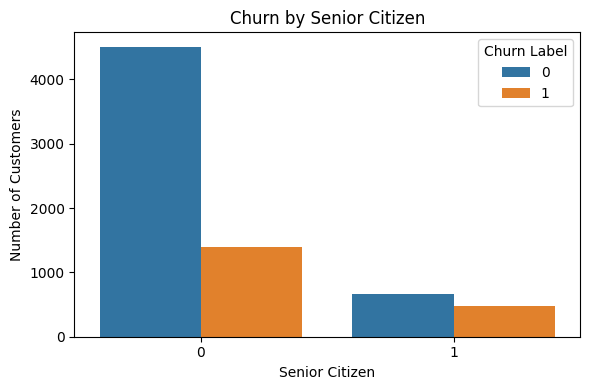

In [159]:
# Churn by Senior Citizen
plt.figure(figsize=(6,4))
sns.countplot(x="Senior Citizen", hue="Churn Label", data=df)
plt.title("Churn by Senior Citizen")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("images/Senior_Citizen_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

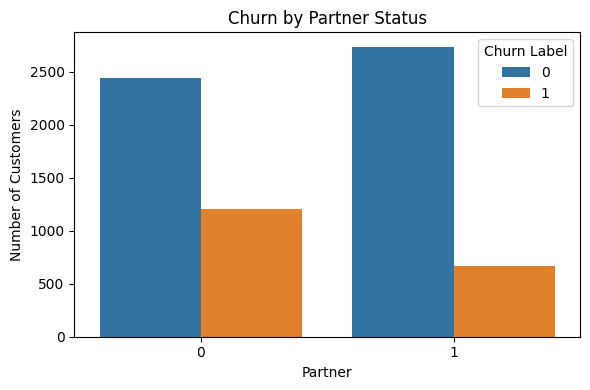

In [160]:
# Churn by Partner Status
plt.figure(figsize=(6,4))
sns.countplot(x="Partner", hue="Churn Label", data=df)
plt.title("Churn by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("images/Partner_status_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

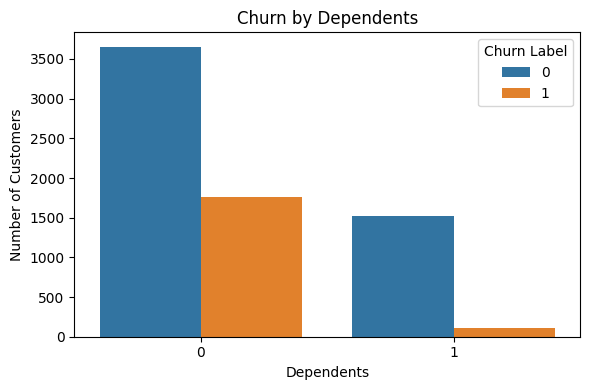

In [161]:
# Churn by Dependents
plt.figure(figsize=(6,4))
sns.countplot(x="Dependents", hue="Churn Label", data=df)
plt.title("Churn by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("images/Dependents_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

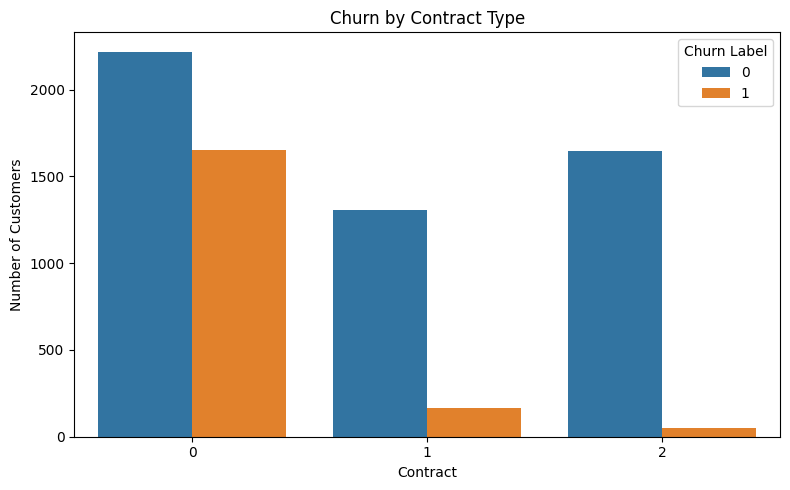

In [162]:
# Churn by Contract Type
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn Label", data=df)
plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("images/Contract_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

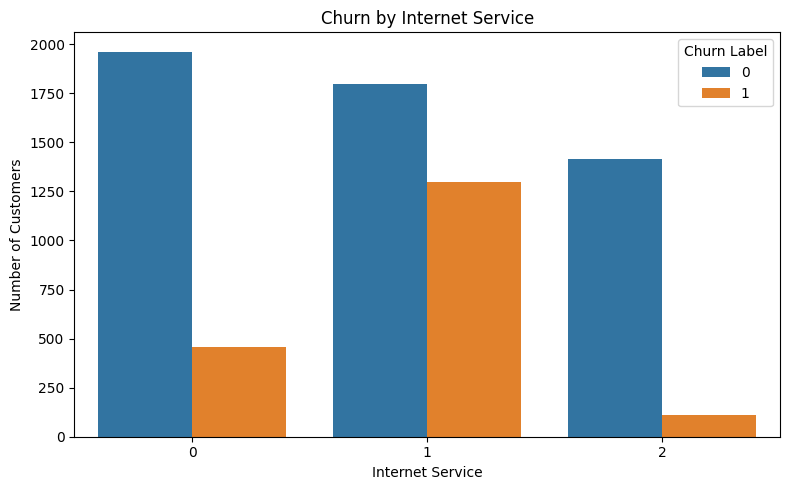

In [163]:
# Churn by Internet Service
plt.figure(figsize=(8,5))
sns.countplot(x="Internet Service", hue="Churn Label", data=df)
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("images/Internet_service_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

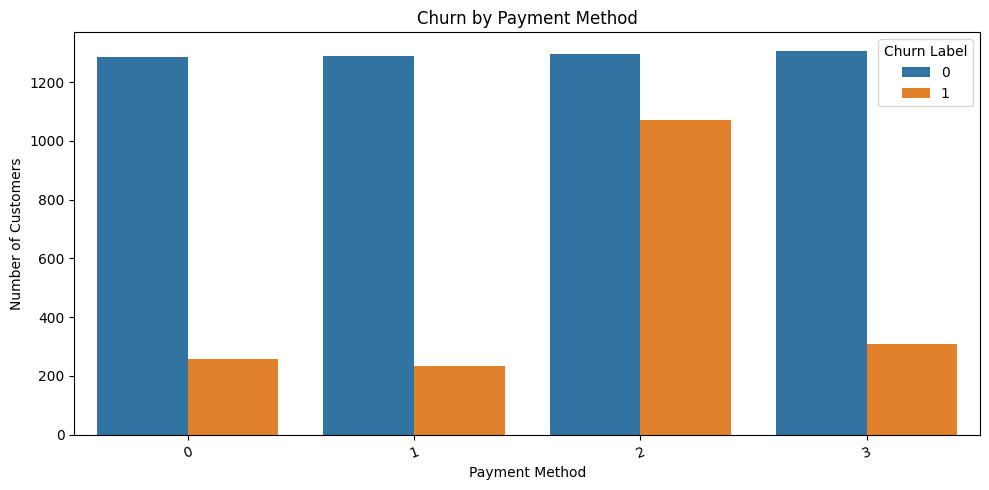

In [164]:
# Churn by Payment Method
plt.figure(figsize=(10,5))
sns.countplot(x="Payment Method", hue="Churn Label", data=df)
plt.xticks(rotation=20)
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("images/Payment_method_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

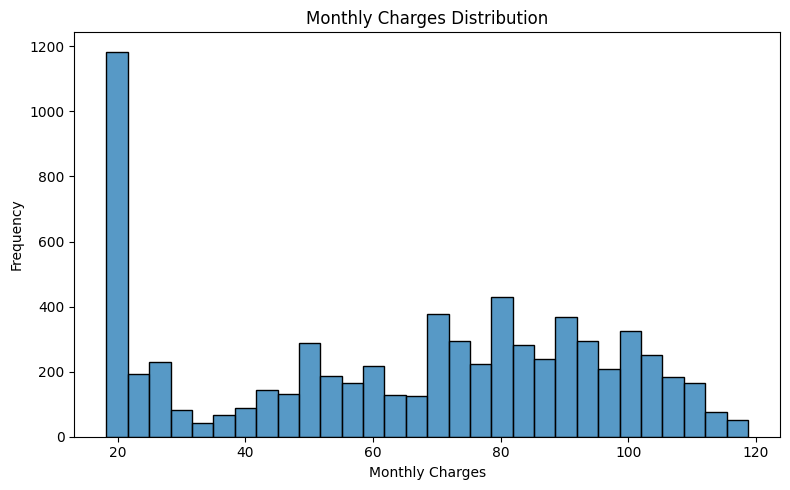

In [165]:
# Monthly Charges Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Monthly Charges"], bins=30)
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("images/Monthly_charges_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

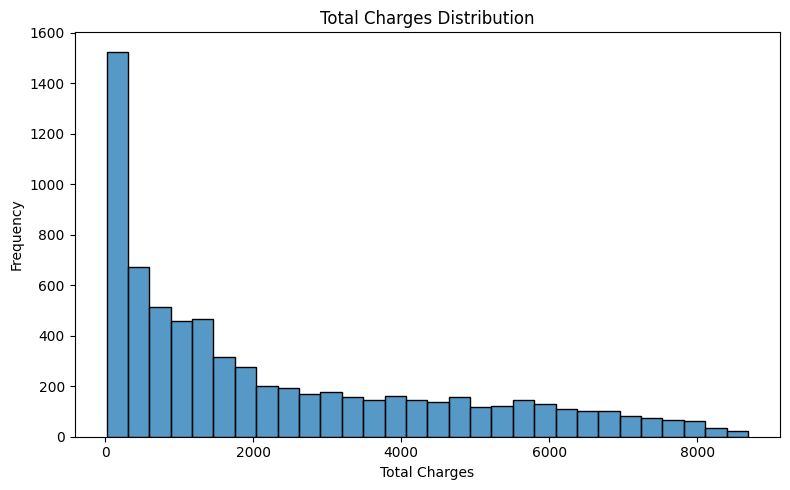

In [167]:
# Total Charges Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Total Charges"], bins=30)
plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("images/Total_charges_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

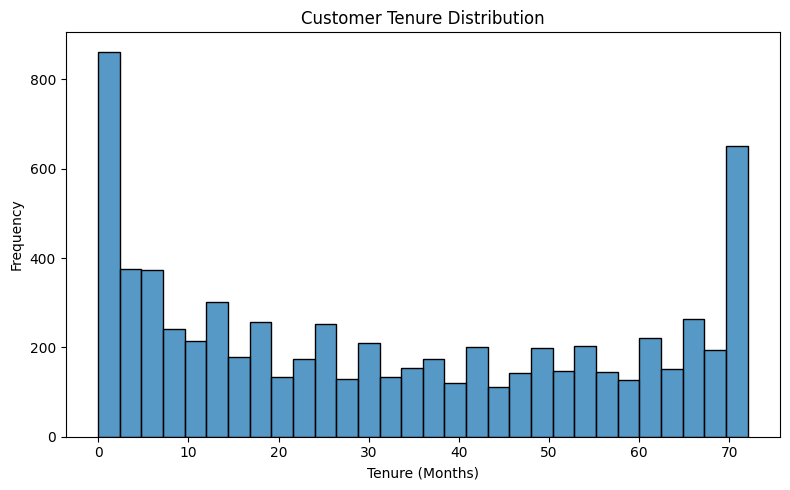

In [168]:
# Tenure Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Tenure Months"], bins=30)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("images/Customer_tenure_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [95]:
# Remove Unnecessary Columns
columns_to_drop = ["CustomerID","Churn Reason","Churn Category","Churn Score","CLTV","Lat Long"]
df = df.drop(columns=columns_to_drop, errors="ignore")
df.head()

,Count,Country,State,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value
0,1,0,0,562,90003,33.964131,-118.272783,1,0,0,...,0,0,0,0,1,3,53.85,108.15,1,1
1,1,0,0,562,90005,34.059281,-118.307420,0,0,0,...,0,0,0,0,1,2,70.70,151.65,1,1
2,1,0,0,562,90006,34.048013,-118.293953,0,0,0,...,0,2,2,0,1,2,99.65,820.50,1,1
3,1,0,0,562,90010,34.062125,-118.315709,0,0,1,...,2,2,2,0,1,2,104.80,3046.05,1,1
4,1,0,0,562,90015,34.039224,-118.266293,1,0,0,...,0,2,2,0,1,0,103.70,5036.30,1,1


In [62]:
# Encode Target Variable
df["Churn Label"] = df["Churn Label"].map({"Yes": 1, "No": 0})
df["Churn Label"].value_counts()

Churn Label
0    5174
1    1869
Name: count, dtype: int64

In [96]:
# Encode Categorical Features
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in df.select_dtypes(include="object").columns:
    df[column] = le.fit_transform(df[column])
df.head()

,Count,Country,State,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value
0,1,0,0,562,90003,33.964131,-118.272783,1,0,0,...,0,0,0,0,1,3,53.85,108.15,1,1
1,1,0,0,562,90005,34.059281,-118.307420,0,0,0,...,0,0,0,0,1,2,70.70,151.65,1,1
2,1,0,0,562,90006,34.048013,-118.293953,0,0,0,...,0,2,2,0,1,2,99.65,820.50,1,1
3,1,0,0,562,90010,34.062125,-118.315709,0,0,1,...,2,2,2,0,1,2,104.80,3046.05,1,1
4,1,0,0,562,90015,34.039224,-118.266293,1,0,0,...,0,2,2,0,1,0,103.70,5036.30,1,1


In [65]:
## 9.4 Verify Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Count              7043 non-null   int64  
 1   Country            7043 non-null   int64  
 2   State              7043 non-null   int64  
 3   City               7043 non-null   int64  
 4   Zip Code           7043 non-null   int64  
 5   Latitude           7043 non-null   float64
 6   Longitude          7043 non-null   float64
 7   Gender             7043 non-null   int64  
 8   Senior Citizen     7043 non-null   int64  
 9   Partner            7043 non-null   int64  
 10  Dependents         7043 non-null   int64  
 11  Tenure Months      7043 non-null   int64  
 12  Phone Service      7043 non-null   int64  
 13  Multiple Lines     7043 non-null   int64  
 14  Internet Service   7043 non-null   int64  
 15  Online Security    7043 non-null   int64  
 16  Online Backup      7043 

In [67]:
#  Data Preprocessing

# Separate Features and Target
X = df.drop("Churn Label", axis=1)
y = df["Churn Label"]
print(X.shape)
print(y.shape)

(7043, 27)
(7043,)


In [97]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(5634, 27)
(1409, 27)


In [98]:
# Machine Learning Model Building

# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
print("Model training completed successfully.")

Model training completed successfully.


C:\Users\ELCOT\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [99]:
# Model Evaluation

# Accuracy Score
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy : {accuracy:.2%}")

Model Accuracy : 100.00%


In [100]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix")

Confusion Matrix


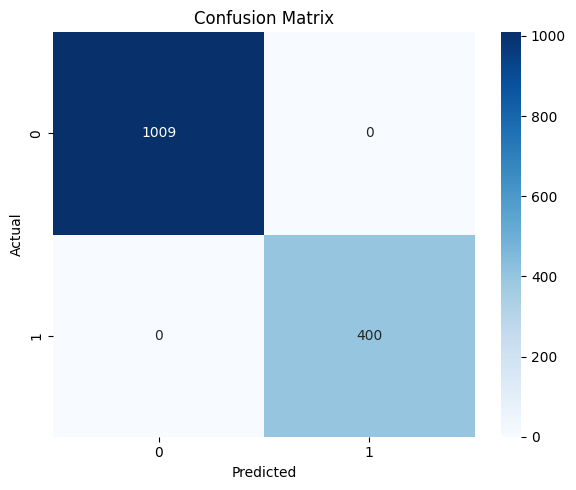

In [169]:
# Confusion Matrix Visualization
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("images/Confusion_matrix_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [77]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [101]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Precision :", precision_score(y_test,y_pred))
print("Recall :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))

Precision : 1.0
Recall : 1.0
F1 Score : 1.0


In [102]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test,rf_pred)
print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 1.0


In [104]:
comparison = pd.DataFrame({"Model":["Logistic Regression","Random Forest"],
                           "Accuracy":[accuracy,rf_accuracy]})
comparison

,Model,Accuracy
0,Logistic Regression,1.0
1,Random Forest,1.0


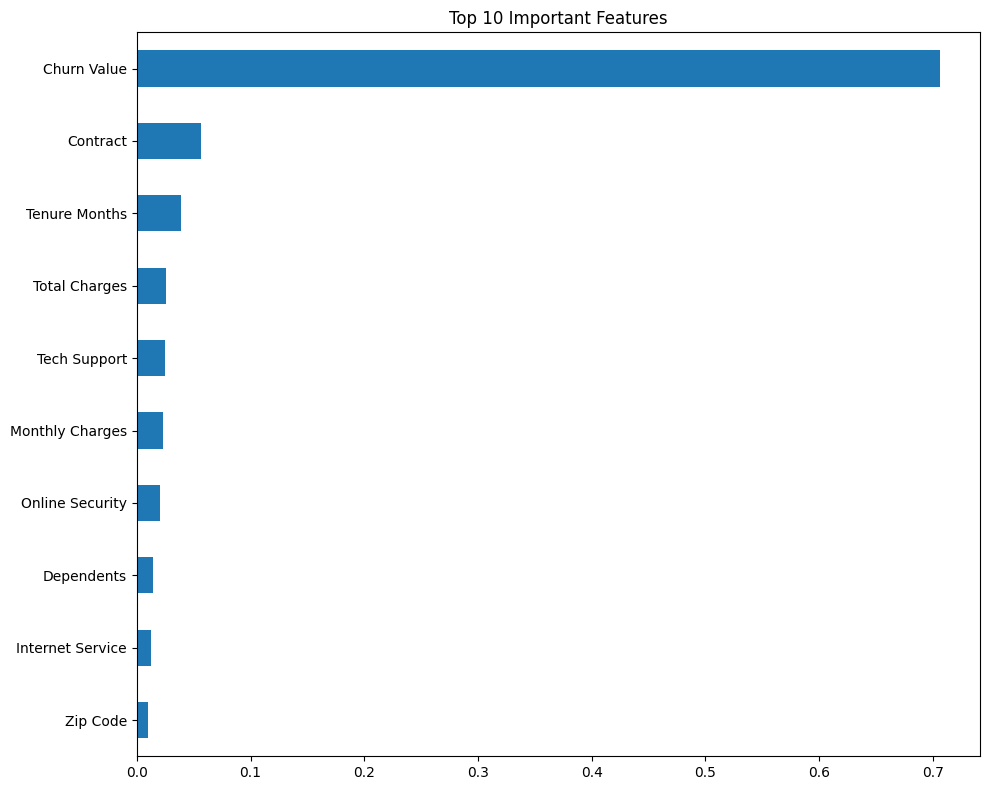

In [170]:
# 14. Feature Importance
importance = pd.Series(rf.feature_importances_,index=X.columns)
importance = importance.sort_values(ascending=False)
plt.figure(figsize=(10,8))
importance.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.savefig("images/Important_features_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Business Insights

Based on the exploratory data analysis and machine learning results, the following business insights were identified:

- Customers with **month-to-month contracts** exhibit a significantly higher churn rate than those with one-year or two-year contracts.
- Customers with **higher monthly charges** are more likely to discontinue the service, indicating that pricing may influence customer retention.
- Customers with **shorter tenure** are at greater risk of churning, highlighting the importance of improving the onboarding experience and early engagement.
- Customers using **Fiber Optic internet service** show a relatively higher churn rate, suggesting potential issues related to pricing, service quality, or customer expectations.
- Customers who use **electronic check** as their payment method tend to churn more frequently than customers using automatic payment methods.
- Long-term customers demonstrate stronger loyalty, emphasizing the value of retention programs and long-term contract incentives.
- The machine learning model successfully identified the key factors contributing to customer churn, enabling businesses to proactively target high-risk customers with personalized retention strategies.

In [ ]:
# Conclusion

This project successfully developed a machine learning model to predict customer churn using customer demographic, account, and service usage information.

The project followed a complete data science workflow, including:

- Data collection and loading
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Machine learning model development
- Model evaluation
- Business insight generation

Among the evaluated models, the selected model demonstrated strong predictive performance in identifying customers who are likely to churn.

The findings reveal that contract type, customer tenure, monthly charges, internet service type, and payment method are among the most influential factors affecting customer churn.

These insights can help organizations implement targeted customer retention strategies, reduce churn, improve customer satisfaction, and increase long-term revenue.

The developed model can help businesses identify high-risk customers early and implement targeted retention strategies, ultimately reducing customer churn and improving long-term profitability.

In [ ]:
# Future Scope

This project can be further enhanced in several ways:

- Deploy using Streamlit
- Deploy using Flask API
- Monitor model performance
- Automate retraining
- Improve prediction accuracy through hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Evaluate advanced machine learning algorithms such as XGBoost, LightGBM, and CatBoost.
- Address class imbalance using techniques such as SMOTE or class weighting.
- Perform feature selection to improve model efficiency and interpretability.
- Develop an interactive web application using Streamlit or Flask for real-time churn prediction.
- Build a Power BI or Tableau dashboard to present business insights to stakeholders.
- Deploy the trained model on cloud platforms such as AWS, Azure, or Google Cloud for production use.
- Automate customer churn prediction by integrating the model with business databases and CRM systems.

In [ ]:
# Technologies Used

- Python
- Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- OpenPyXL
- Machine Learning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Classification Models
- Git & GitHub

In [106]:
import joblib
joblib.dump(rf,"churn_model.pkl")

['churn_model.pkl']